In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [ ]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [ ]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [8]:
RANDOM_SEED = 42

## Baseline 2: Bayesian CNN

#### 50% Unlabeled Rate

#### 75% Unlabeled Rate

In [62]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_75 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_75 = SSLDataset(train_dataset, train_labels_ssl_75)
train_ssl_loader_75 = data.DataLoader(train_ssl_dataset_75, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [ ]:
ssl_bmodel_75, criterion, optimizer = default_setup(lr=0.0001, rho_init=-7.0)
bcnn_history_75 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_75, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=0.0, num_samples=10)

rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
beta:0.0


100%|██████████| 8/8 [00:02<00:00,  3.99it/s]


Epoch 1/20 | Train NLL: 1.4803 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.2374 | Val AUC Macro: 0.5998 | Val AUC Global: 0.8857


100%|██████████| 8/8 [00:01<00:00,  4.15it/s]


Epoch 2/20 | Train NLL: 0.9315 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.8923 | Val AUC Macro: 0.8304 | Val AUC Global: 0.9311


...

Epoch 18/20 | Train NLL: 0.5872 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.7259 | Val AUC Macro: 0.9115 | Val AUC Global: 0.9571


100%|██████████| 8/8 [00:02<00:00,  3.92it/s]


Epoch 19/20 | Train NLL: 0.5634 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.7167 | Val AUC Macro: 0.9134 | Val AUC Global: 0.9570


100%|██████████| 8/8 [00:02<00:00,  3.89it/s]

Epoch 20/20 | Train NLL: 0.5399 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.7667 | Val AUC Macro: 0.9030 | Val AUC Global: 0.9513


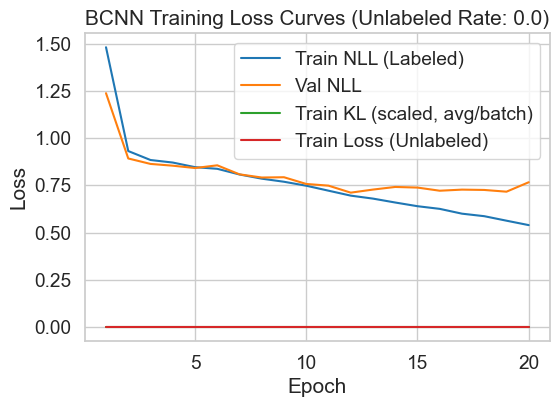

In [107]:
plot_loss_curves_bcnn(bcnn_history_75, unlabeled_rate=unlabeled_rate, use_unlabeled=True)

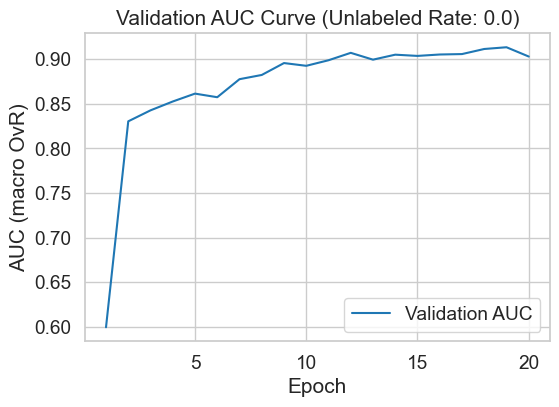

In [108]:
plot_auc_curve(bcnn_history_75, unlabeled_rate=unlabeled_rate)

In [109]:
best_bcnn_history_75 = max(bcnn_history_75, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_history_75['epoch']} | Val AUC Macro: {best_bcnn_history_75['val_auc_macro']:.4f}")

best_bcnn_model_75 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_75.load_state_dict(best_bcnn_history_75['model_state'])

Best Epoch: 19 | Val AUC Macro: 0.9134
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
rho_init lin: -10.0


<All keys matched successfully>

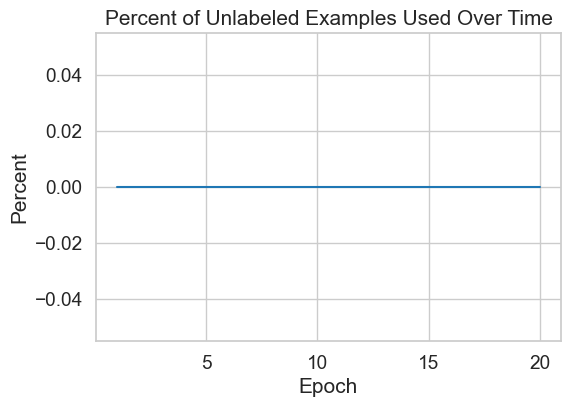

In [110]:
plot_percent_unlabeled_used(bcnn_history_75)

In [111]:
# test_results_bcnn_75 = evaluate_bayesian(best_bcnn_model_75, test_loader, device='cpu')
# test_results_bcnn_75

In [112]:
# plot_per_class_recall(test_results_bcnn_75['confusion_matrix'], list(short_labels.values()))

In [113]:
with torch.no_grad():
    best_bcnn_model_75.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_bcnn_model_75.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:02<00:00,  2.82it/s]

Percentage of predictions that are class 5: 70.7%


In [114]:
model = VariationalCNN(n_channels, n_classes)
x = torch.randn(4, 3, 28, 28)

# check activations at each layer
with torch.no_grad():
    x1 = model.layer1(x)
    x2 = model.layer2(x1)
    x3 = model.layer3(x2)
    x4 = model.layer4(x3)
    x5 = model.layer5(x4)
    xf = x5.view(x5.size(0), -1)
    out = model.fc(xf)
    
    print(f"Layer 1 output: mean={x1.mean():.4f}, std={x1.std():.4f}")
    print(f"Layer 2 output: mean={x2.mean():.4f}, std={x2.std():.4f}")
    print(f"Layer 3 output: mean={x3.mean():.4f}, std={x3.std():.4f}")
    print(f"Layer 4 output: mean={x4.mean():.4f}, std={x4.std():.4f}")
    print(f"Layer 5 output: mean={x5.mean():.4f}, std={x5.std():.4f}")
    print(f"Output logits: mean={out.mean():.4f}, std={out.std():.4f}")

rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
Layer 1 output: mean=0.3974, std=0.5821
Layer 2 output: mean=1.0490, std=0.6762
Layer 3 output: mean=0.3983, std=0.5813
Layer 4 output: mean=0.3993, std=0.5848
Layer 5 output: mean=1.0340, std=0.6724
Output logits: mean=-0.0010, std=0.0028


In [115]:
model = VariationalCNN(n_channels, n_classes)
model.eval()
images, labels = next(iter(test_loader))
images = images[:5]
labels = labels[:5].squeeze()

with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

print("Logits:")
print(logits.numpy())
print("\nProbs:")
print(probs.numpy())
print("\nPredictions:", preds.numpy())
print("True labels:", labels.numpy())

rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
Logits:
[[ 4.17079827e-05 -4.30982946e-05  3.09950483e-05  4.67767177e-06
   1.61223124e-05 -1.03155508e-04 -6.03507251e-05]
 [ 4.17049014e-05 -4.30738801e-05  3.10066789e-05  4.67268001e-06
   1.61228018e-05 -1.03165818e-04 -6.03429762e-05]
 [ 4.17042174e-05 -4.30751934e-05  3.10071118e-05  4.67465316e-06
   1.61215103e-05 -1.03164522e-04 -6.03426633e-05]
 [ 4.17067495e-05 -4.30748405e-05  3.10039613e-05  4.67411610e-06
   1.61210355e-05 -1.03163584e-04 -6.03413828e-05]
 [ 4.17094707e-05 -4.30779219e-05  3.10048999e-05  4.67653854e-06
   1.61197095e-05 -1.03161015e-04 -6.03426633e-05]]

Probs:
[[0.1428654  0.14285329 0.14286387 0.14286011 0.14286175 0.1428447
  0.14285083]
 [0.1428654  0.14285329 0.14286388 0.14286011 0.14286175 0.1428447
  0.14285083]
 [0.1428654  0.14285329 0.14286388 0.14286011 0.14286175 0.1428447
  0.

In [116]:
best_bcnn_model_75.eval()
images, labels = next(iter(test_loader))
images = images[:5]
labels = labels[:5].squeeze()

with torch.no_grad():
    logits = best_bcnn_model_75(images)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

print("Logits:")
print(logits.numpy())
print("\nProbs:")
print(probs.numpy())
print("\nPredictions:", preds.numpy())
print("True labels:", labels.numpy())

Logits:
[[-4.38918    -3.4876668  -1.1587342  -3.2501855   1.0352296   3.101413
  -1.6890988 ]
 [ 0.00872221  1.152444   -0.4343231   0.04297153 -1.9368494   0.16436478
   0.1482927 ]
 [-1.446368   -2.122113    1.6967473  -3.2821002   0.89124125  0.2517951
  -5.705968  ]
 [-1.9550035  -2.0594509   0.5003099  -2.5558562   0.8280689   0.9724106
  -3.2773814 ]
 [-5.0593977  -5.0253696  -0.95142585 -4.104604    2.8689795   3.284641
  -2.5300598 ]]

Probs:
[[4.8432019e-04 1.1930392e-03 1.2248908e-02 1.5128347e-03 1.0988126e-01
  8.6747259e-01 7.2071375e-03]
 [1.2082487e-01 3.7920007e-01 7.7579007e-02 1.2503472e-01 1.7266538e-02
  1.4117281e-01 1.3892201e-01]
 [2.4582889e-02 1.2507213e-02 5.6973189e-01 3.9208890e-03 2.5459138e-01
  1.3431847e-01 3.4730590e-04]
 [2.0319570e-02 1.8304322e-02 2.3672472e-01 1.1142111e-02 3.2853946e-01
  3.7955469e-01 5.4151826e-03]
 [1.4168398e-04 1.4658817e-04 8.6176796e-03 3.6811410e-04 3.9316177e-01
  5.9578669e-01 1.7774533e-03]]

Predictions: [5 1 2 5 5]
Tr

#### 90% Unlabeled Rate

## Debugging BCNN initialization issues

In [124]:
rhos = [-10.0, -7.0, -5.0, -2.25]
all_history = []
for rho in rhos:
    model, criterion, optimizer = default_setup(lr=0.0001, rho_init=rho)
    history = train_loop_bcnn_hard_pseudo_label(model, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=0.0, num_samples=10)
    all_history.append({
        'rho_init': rho,
        'history': history
    })

rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init conv: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
rho_init lin: -10.0
beta:0.0


100%|██████████| 8/8 [00:01<00:00,  4.24it/s]


Epoch 1/20 | Train NLL: 1.4708 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.2434 | Val AUC Macro: 0.7723 | Val AUC Global: 0.9100


100%|██████████| 8/8 [00:01<00:00,  4.27it/s]


Epoch 2/20 | Train NLL: 0.9330 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.9148 | Val AUC Macro: 0.8405 | Val AUC Global: 0.9312


...

Epoch 18/20 | Train NLL: 1.3855 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.1832 | Val AUC Macro: 0.5689 | Val AUC Global: 0.8646


100%|██████████| 8/8 [00:01<00:00,  4.12it/s]


Epoch 19/20 | Train NLL: 1.3915 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.2043 | Val AUC Macro: 0.5468 | Val AUC Global: 0.8689


100%|██████████| 8/8 [00:01<00:00,  4.11it/s]

Epoch 20/20 | Train NLL: 1.3793 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.2097 | Val AUC Macro: 0.5441 | Val AUC Global: 0.8711


In [126]:
for result in all_history:
    best = max(result['history'], key=lambda x: x['val_auc_macro'])
    print(f"rho={result['rho_init']} | Best Val AUC: {best['val_auc_macro']:.4f} | Epoch: {best['epoch']}")

rho=-10.0 | Best Val AUC: 0.9048 | Epoch: 20
rho=-7.0 | Best Val AUC: 0.9085 | Epoch: 20
rho=-5.0 | Best Val AUC: 0.8835 | Epoch: 20
rho=-2.25 | Best Val AUC: 0.5719 | Epoch: 16


### Try again

In [128]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [129]:
ssl_bmodel_50, criterion, optimizer = default_setup(lr=0.0001, rho_init=-7.0)
bcnn_history_50 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=0.0, num_samples=10)

rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
beta:0.0


100%|██████████| 8/8 [00:01<00:00,  4.41it/s]


Epoch 1/20 | Train NLL: 1.5555 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.2818 | Val Loss: 1.0142 | Val AUC Macro: 0.7854 | Val AUC Global: 0.9092


100%|██████████| 8/8 [00:01<00:00,  4.36it/s]


Epoch 2/20 | Train NLL: 1.0028 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.1486 | Val Loss: 0.9368 | Val AUC Macro: 0.8191 | Val AUC Global: 0.9294


...

Epoch 18/20 | Train NLL: 0.7007 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0186 | Val Loss: 0.7471 | Val AUC Macro: 0.9028 | Val AUC Global: 0.9533


100%|██████████| 8/8 [00:01<00:00,  4.27it/s]


Epoch 19/20 | Train NLL: 0.6893 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0219 | Val Loss: 0.7482 | Val AUC Macro: 0.9059 | Val AUC Global: 0.9537


100%|██████████| 8/8 [00:01<00:00,  4.15it/s]

Epoch 20/20 | Train NLL: 0.6800 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0157 | Val Loss: 0.7407 | Val AUC Macro: 0.9047 | Val AUC Global: 0.9543


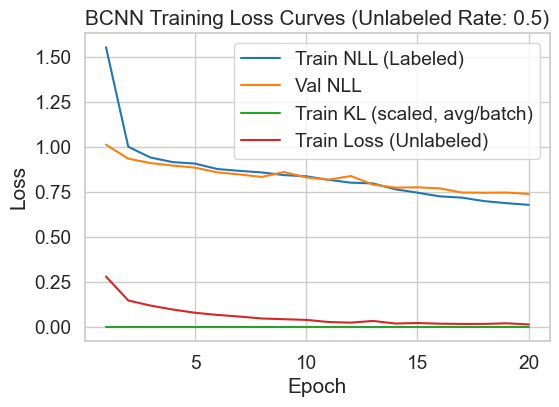

In [130]:
plot_loss_curves_bcnn(bcnn_history_50, unlabeled_rate=unlabeled_rate, use_unlabeled=True)

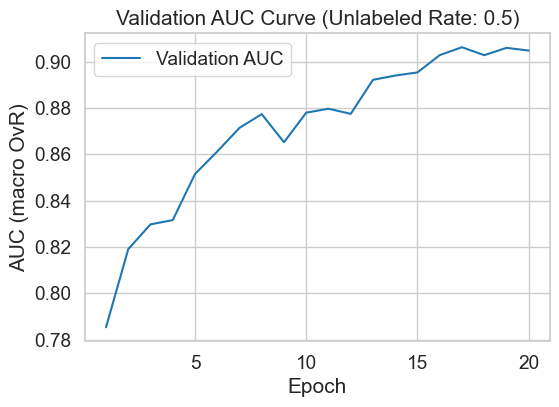

In [131]:
plot_auc_curve(bcnn_history_50, unlabeled_rate=unlabeled_rate)

In [132]:
best_bcnn_history_50 = max(bcnn_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_history_50['epoch']} | Val AUC Macro: {best_bcnn_history_50['val_auc_macro']:.4f}")

best_bcnn_model_50 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_50.load_state_dict(best_bcnn_history_50['model_state'])

Best Epoch: 17 | Val AUC Macro: 0.9062
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init lin: -2.25
rho_init lin: -2.25
rho_init lin: -2.25


<All keys matched successfully>

#### try adding KL term back in

In [133]:
ssl_bmodel_50, criterion, optimizer = default_setup(lr=0.0001, rho_init=-7.0)
bcnn_history_50 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=1.0, num_samples=10)

rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
beta:1.0


100%|██████████| 8/8 [00:01<00:00,  4.48it/s]


Epoch 1/20 | Train NLL: 1.5743 | Train KL (avg/batch): 3.2459 | Train Loss Unlabeled: 0.2976 | Val Loss: 0.9886 | Val AUC Macro: 0.7898 | Val AUC Global: 0.9168


100%|██████████| 8/8 [00:01<00:00,  4.37it/s]


Epoch 2/20 | Train NLL: 0.9839 | Train KL (avg/batch): 3.2436 | Train Loss Unlabeled: 0.1485 | Val Loss: 0.9270 | Val AUC Macro: 0.8069 | Val AUC Global: 0.9280


...

Epoch 18/20 | Train NLL: 0.6692 | Train KL (avg/batch): 3.2122 | Train Loss Unlabeled: 0.0219 | Val Loss: 0.7526 | Val AUC Macro: 0.8973 | Val AUC Global: 0.9531


100%|██████████| 8/8 [00:01<00:00,  4.07it/s]


Epoch 19/20 | Train NLL: 0.6730 | Train KL (avg/batch): 3.2104 | Train Loss Unlabeled: 0.0220 | Val Loss: 0.7403 | Val AUC Macro: 0.9001 | Val AUC Global: 0.9538


100%|██████████| 8/8 [00:01<00:00,  4.27it/s]


Epoch 20/20 | Train NLL: 0.6512 | Train KL (avg/batch): 3.2086 | Train Loss Unlabeled: 0.0193 | Val Loss: 0.7426 | Val AUC Macro: 0.8999 | Val AUC Global: 0.9539


In [136]:
ssl_bmodel_50.eval()
for name, module in ssl_bmodel_50.named_modules():
    if isinstance(module, (VariationalConv2DLayer, VariationalLinearLayer)):
        sigma_w = torch.nn.functional.softplus(module.r_w)
        sigma_bias = torch.nn.functional.softplus(module.r_bias)
        print(f"{name} | mu_w mean: {module.mu_w.abs().mean():.4f} | sigma_w mean: {sigma_w.mean():.4f} | sigma_bias mean: {sigma_bias.mean():.4f}")

layer1.0 | mu_w mean: 0.0088 | sigma_w mean: 0.0009 | sigma_bias mean: 0.0010
layer2.0 | mu_w mean: 0.0084 | sigma_w mean: 0.0009 | sigma_bias mean: 0.0010
layer3.0 | mu_w mean: 0.0087 | sigma_w mean: 0.0009 | sigma_bias mean: 0.0010
layer4.0 | mu_w mean: 0.0086 | sigma_w mean: 0.0009 | sigma_bias mean: 0.0010
layer5.0 | mu_w mean: 0.0086 | sigma_w mean: 0.0010 | sigma_bias mean: 0.0010
fc.0 | mu_w mean: 0.0120 | sigma_w mean: 0.0010 | sigma_bias mean: 0.0010
fc.2 | mu_w mean: 0.0113 | sigma_w mean: 0.0010 | sigma_bias mean: 0.0010
fc.4 | mu_w mean: 0.0125 | sigma_w mean: 0.0010 | sigma_bias mean: 0.0009


In [138]:
model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-7.0)
images, labels = next(iter(train_ssl_loader_50))
label_mask = (labels != -1).squeeze()
inputs = images[label_mask]
targets = labels[label_mask].squeeze().long()

outputs = model(inputs)
loss, nll, kl = elbo_loss(model, outputs, targets, criterion, beta=1.0)
loss.backward()

print(f"r_w gradient for layer1: {model.layer1[0].r_w.grad.abs().mean():.6f}")
print(f"mu_w gradient for layer1: {model.layer1[0].mu_w.grad.abs().mean():.6f}")

rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init conv: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
rho_init lin: -7.0
r_w gradient for layer1: 0.000003
mu_w gradient for layer1: 0.002594
